Generating box plots for each metric by method...


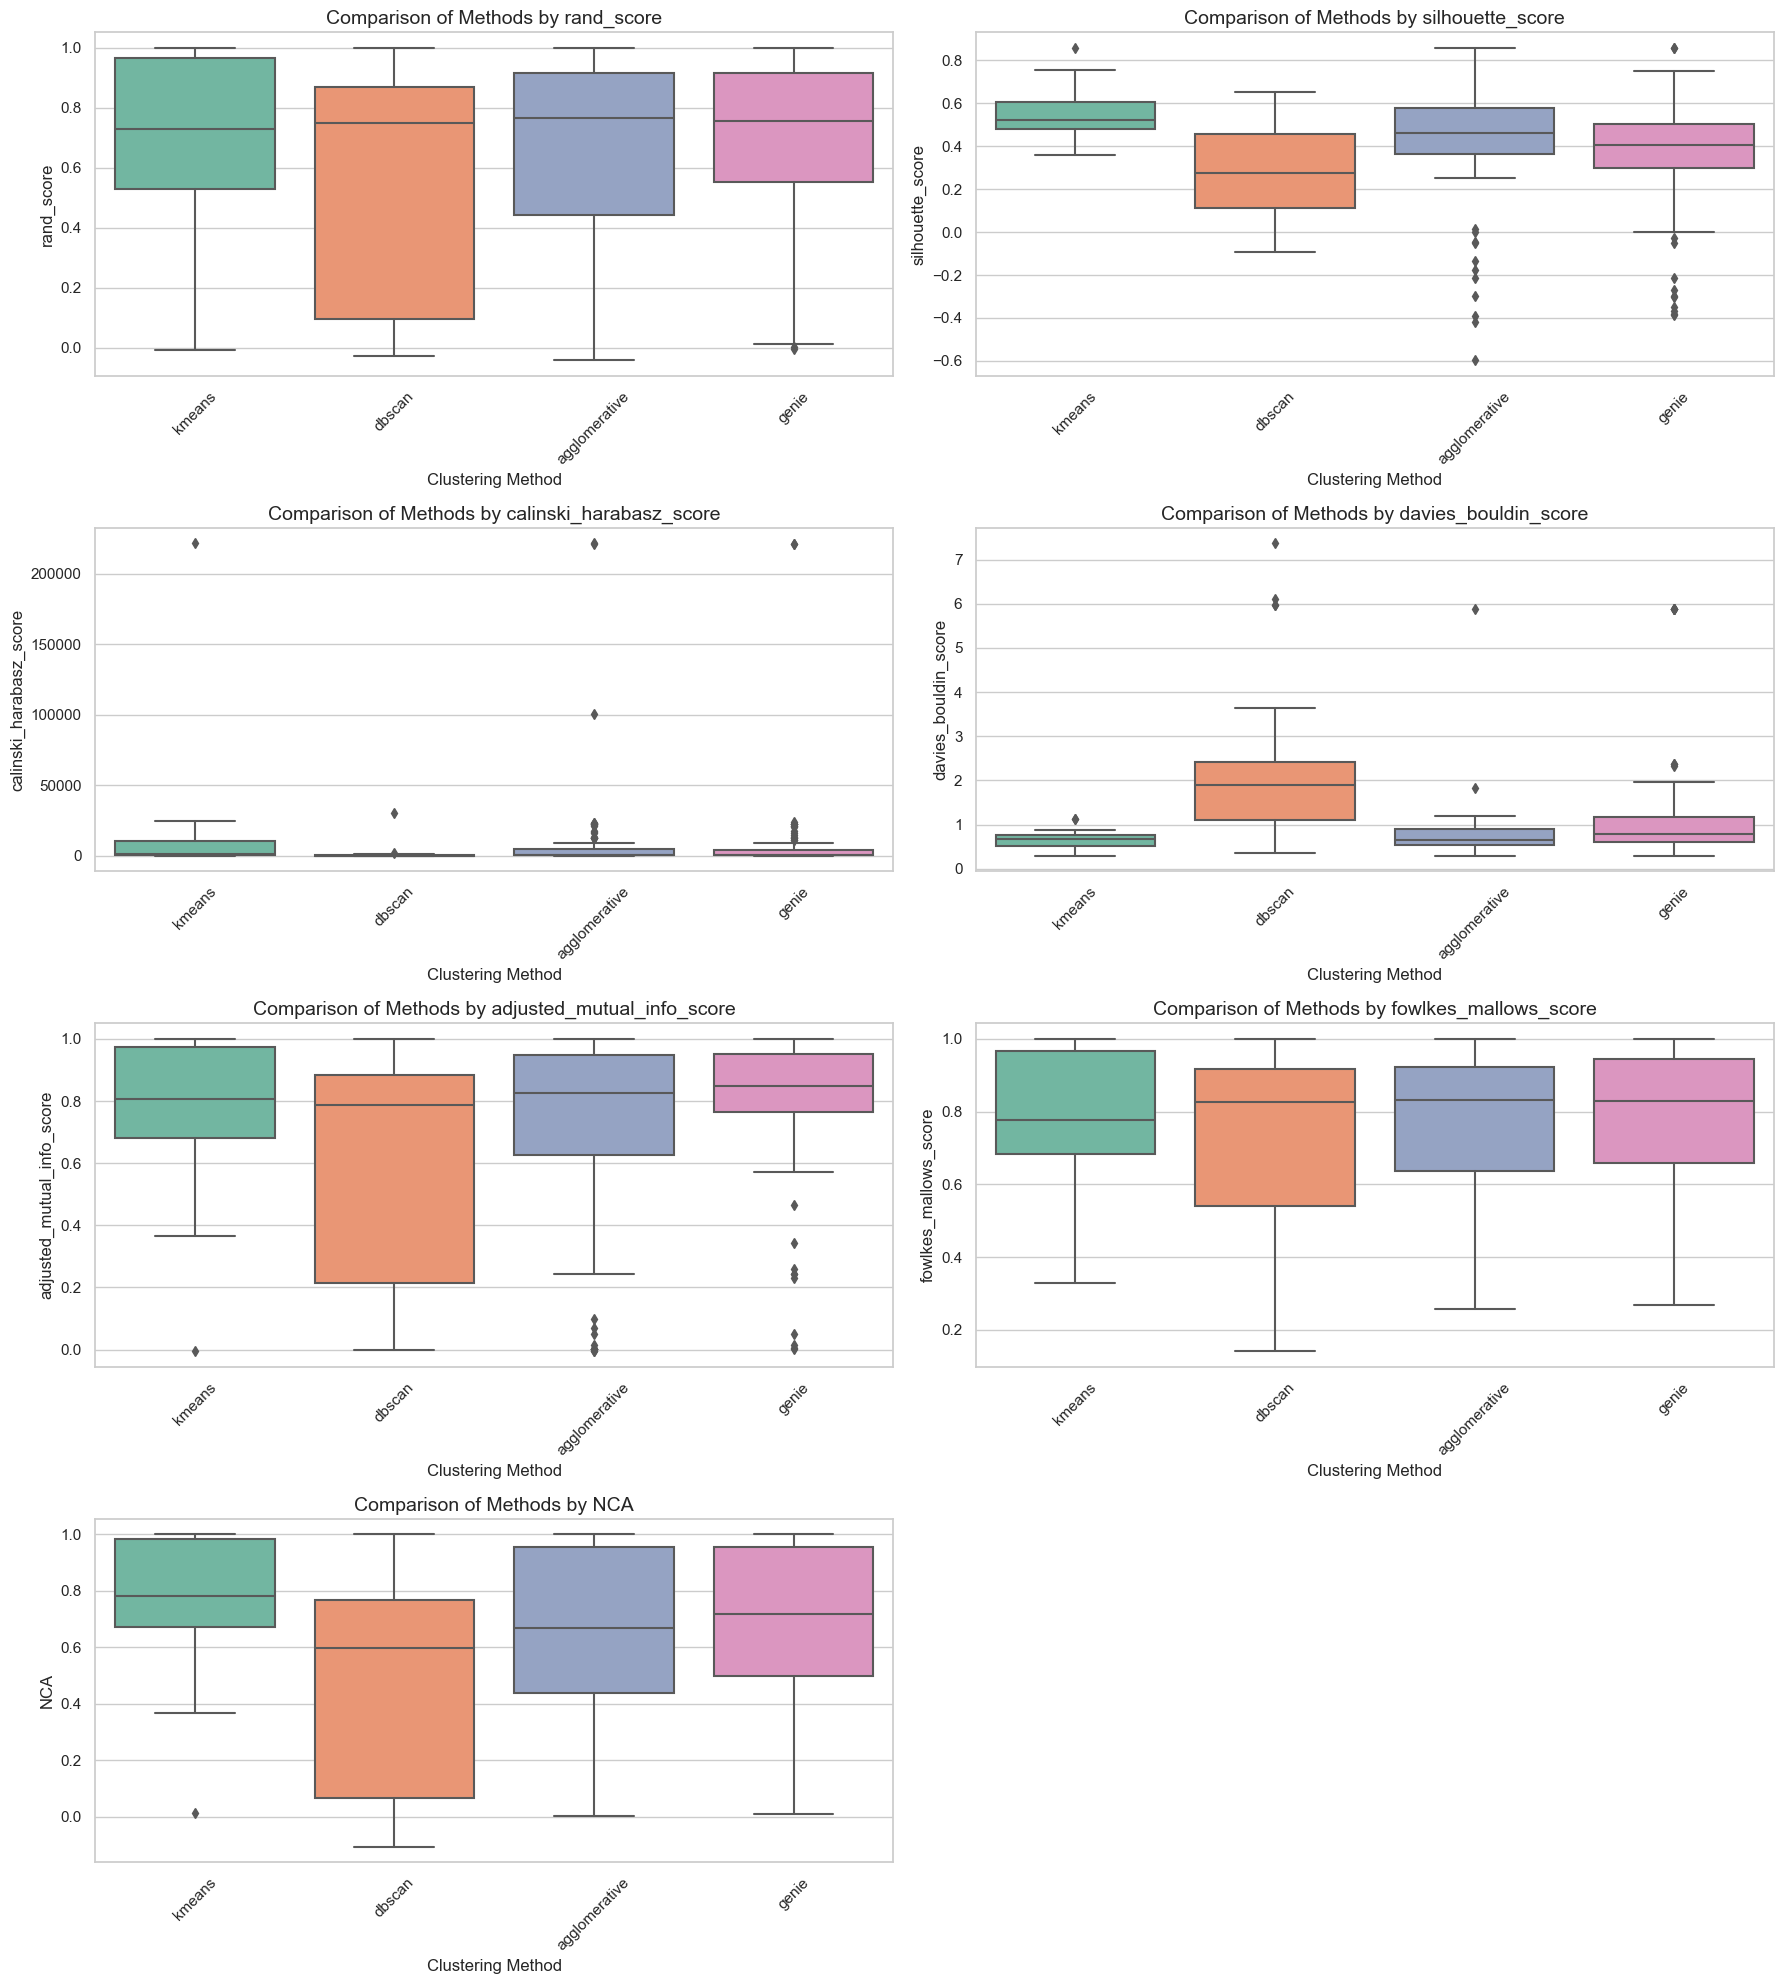


Generating scatter plots by number of clusters...


/Users/mat/opt/anaconda3/envs/asseco/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/mat/opt/anaconda3/envs/asseco/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


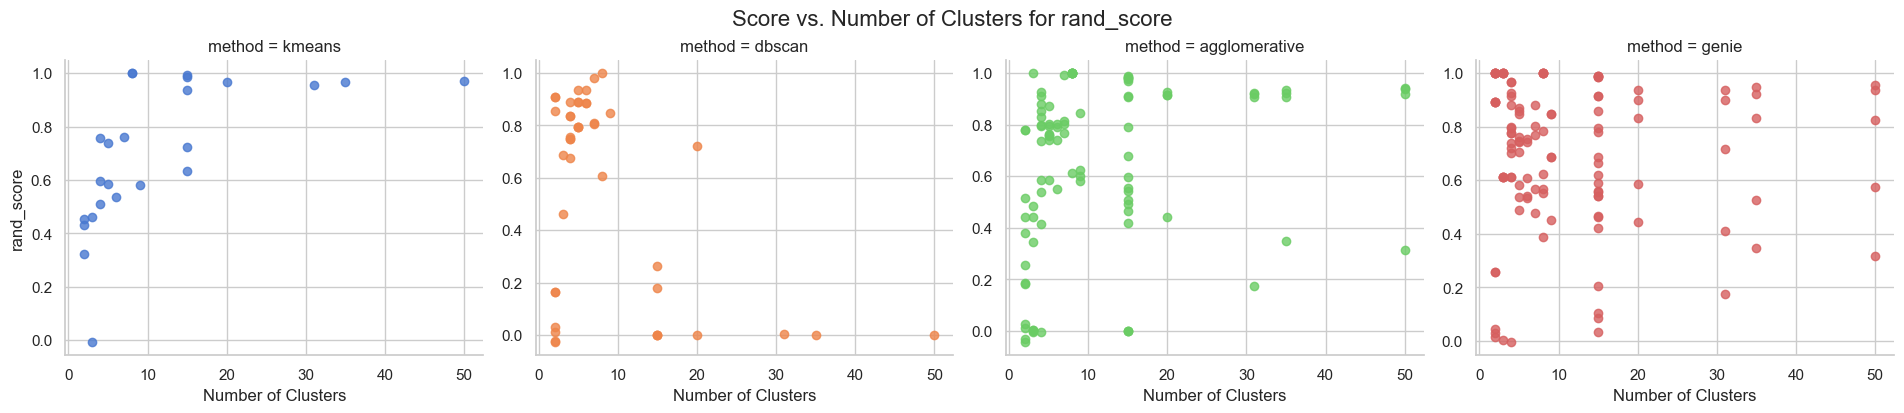

/Users/mat/opt/anaconda3/envs/asseco/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/mat/opt/anaconda3/envs/asseco/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


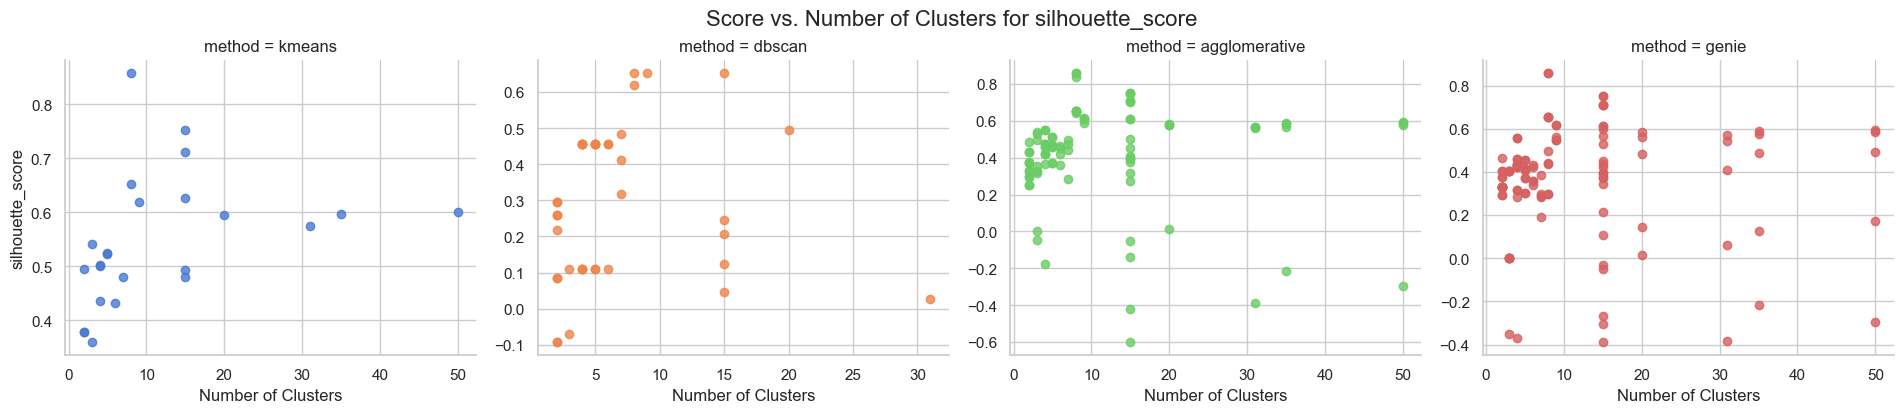

/Users/mat/opt/anaconda3/envs/asseco/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/mat/opt/anaconda3/envs/asseco/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


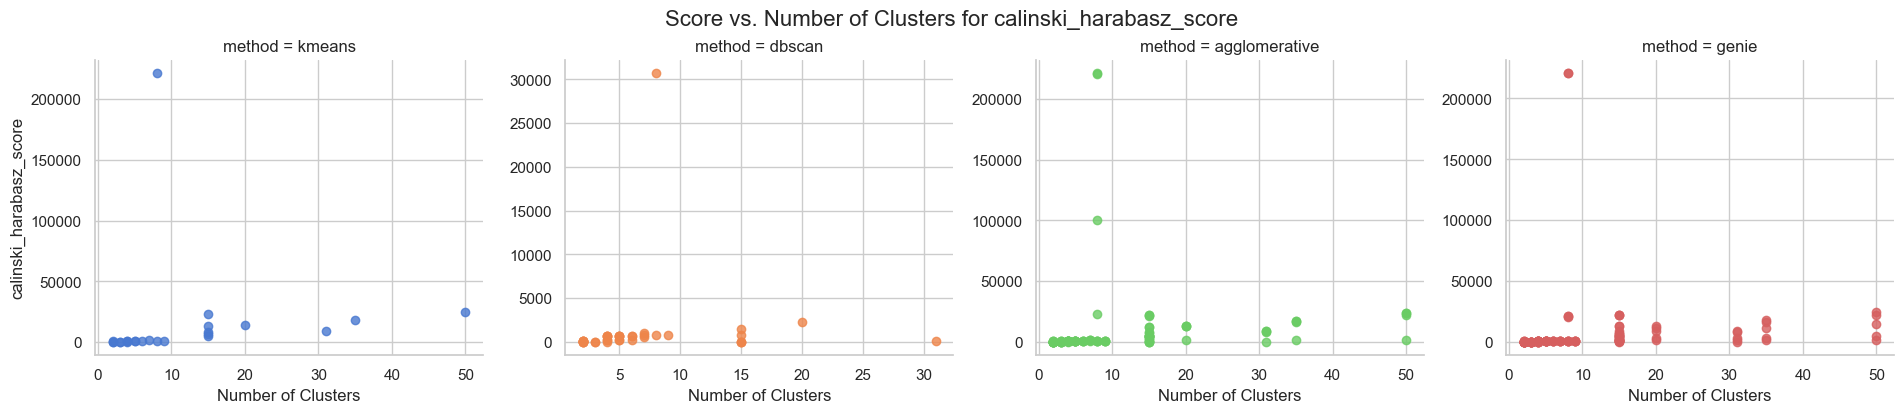

/Users/mat/opt/anaconda3/envs/asseco/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/mat/opt/anaconda3/envs/asseco/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


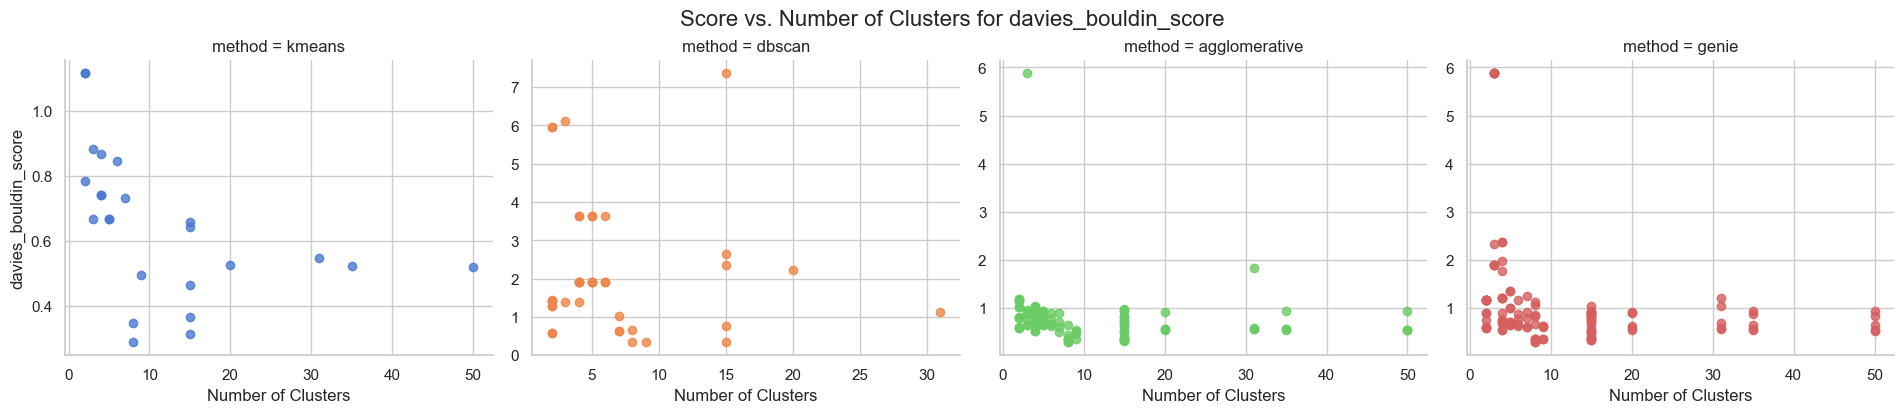

/Users/mat/opt/anaconda3/envs/asseco/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/mat/opt/anaconda3/envs/asseco/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


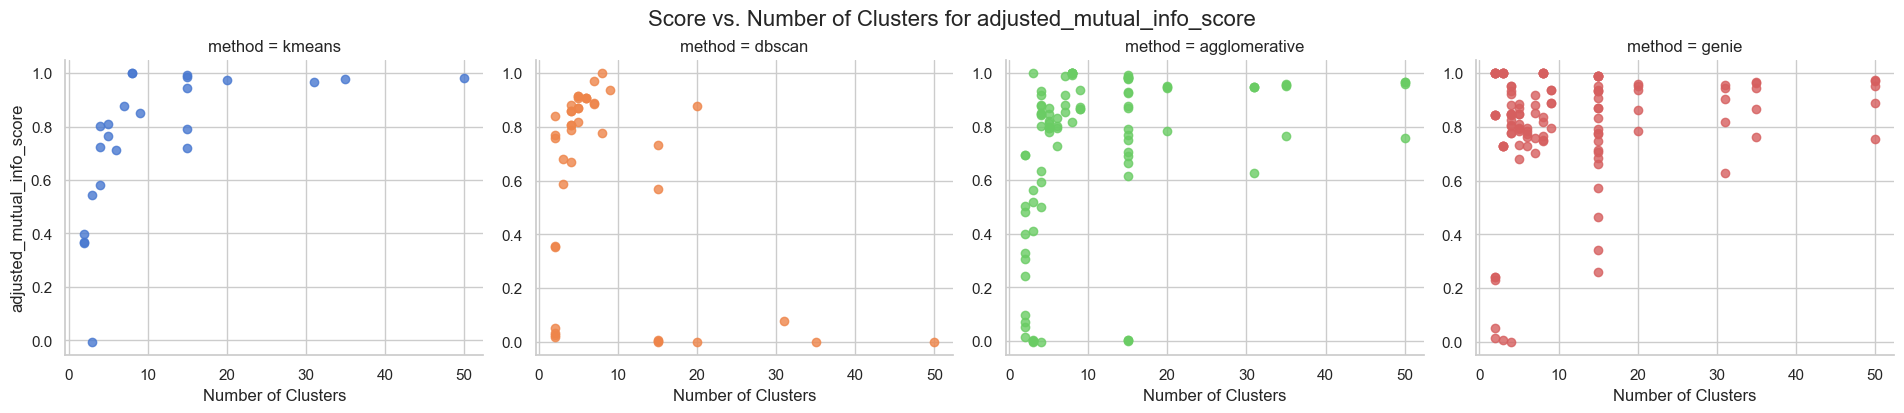

/Users/mat/opt/anaconda3/envs/asseco/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/mat/opt/anaconda3/envs/asseco/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


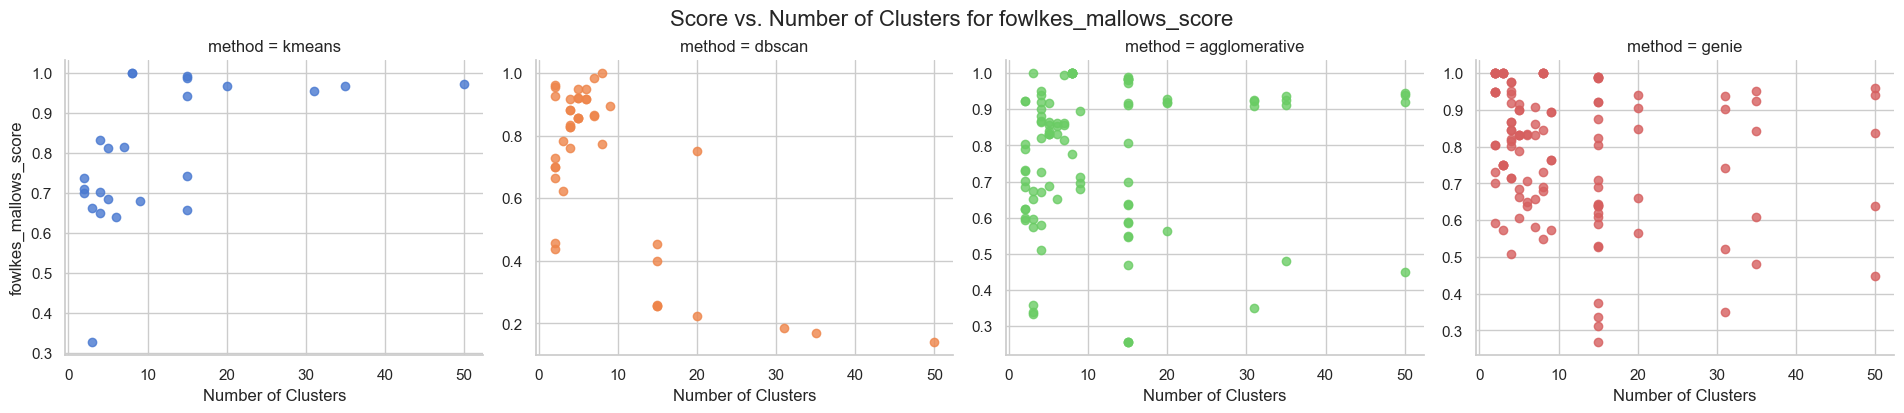

/Users/mat/opt/anaconda3/envs/asseco/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/mat/opt/anaconda3/envs/asseco/lib/python3.10/site-packages/seaborn/regression.py:582: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


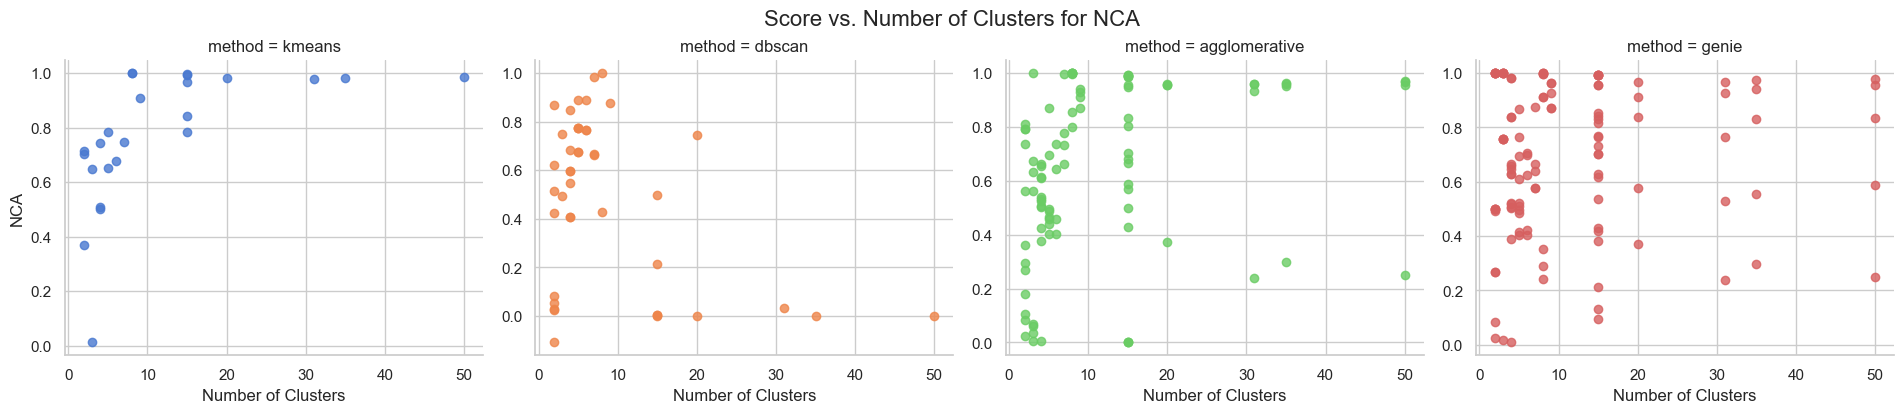


Generating hyperparameter heatmaps...


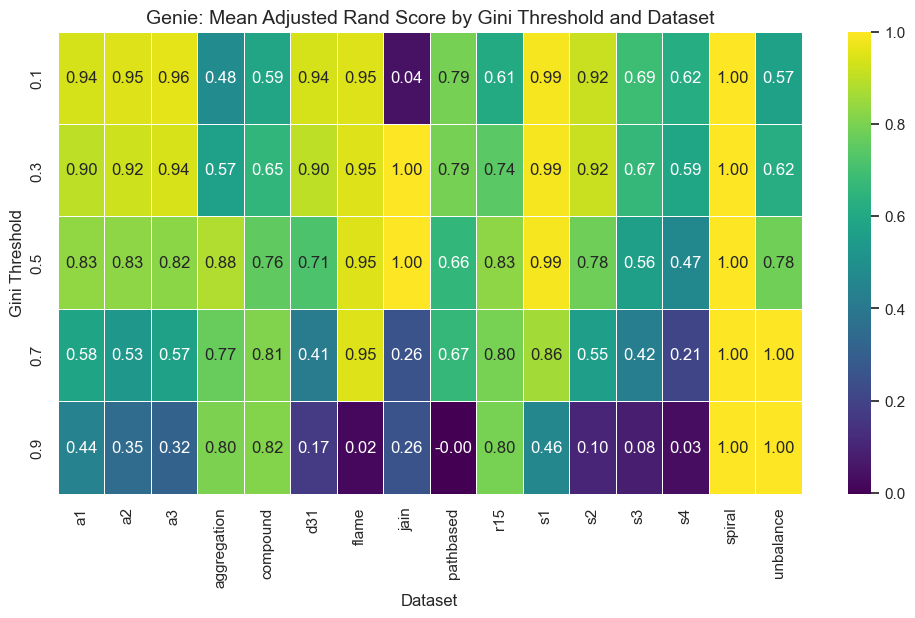

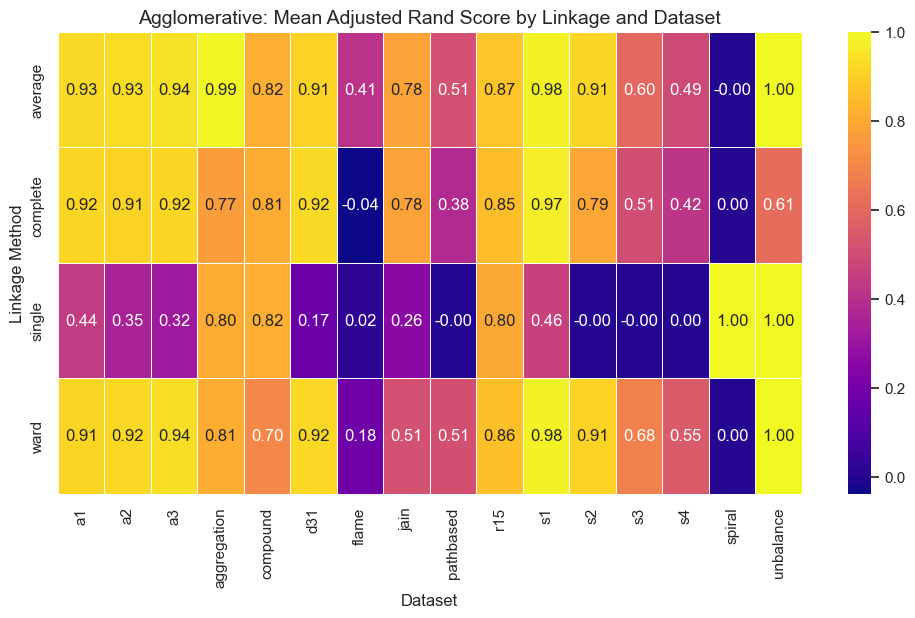

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


class ResultVisualizer:
    def __init__(self, results_filepath: str):
        """
        Initialize the visualizer with the path to the results CSV file.

        Args:
            results_filepath (str): The path to the 'results.csv' file.
        """
        if not os.path.exists(results_filepath):
            raise FileNotFoundError(f"The file '{results_filepath}' was not found.")

        self.df = pd.read_csv(results_filepath)
        self.metrics = [
            "rand_score",
            "silhouette_score",
            "calinski_harabasz_score",
            "davies_bouldin_score",
            "adjusted_mutual_info_score",
            "fowlkes_mallows_score",
            "NCA",
        ]
        # Set a nice style for the plots
        sns.set_theme(style="whitegrid")

    def plot_boxplots_by_method(self):
        """
        Generate box plots for each metric, comparing the performance of each
        base clustering method.
        """
        print("Generating box plots for each metric by method...")

        # Calculate the number of rows needed
        n_metrics = len(self.metrics)
        n_cols = 2
        n_rows = (n_metrics + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
        axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

        for i, metric in enumerate(self.metrics):
            ax = axes[i]
            sns.boxplot(x="method", y=metric, data=self.df, ax=ax, palette="Set2")
            ax.set_title(f"Comparison of Methods by {metric}", fontsize=14)
            ax.set_xlabel("Clustering Method", fontsize=12)
            ax.set_ylabel(metric, fontsize=12)
            ax.tick_params(axis="x", rotation=45)

        # Hide any unused subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    def plot_scatter_by_n_clusters(self):
        """
        Generate scatter plots to show the relationship between the number
        of clusters and each metric score, faceted by method.
        """
        print("\nGenerating scatter plots by number of clusters...")
        for metric in self.metrics:
            g = sns.lmplot(
                x="n_clusters",
                y=metric,
                hue="method",
                data=self.df,
                col="method",
                col_wrap=4,
                sharex=False,
                sharey=False,
                palette="muted",
                fit_reg=False,
                height=4,
                aspect=1.2,
            )
            g.fig.suptitle(
                f"Score vs. Number of Clusters for {metric}", y=1.03, fontsize=16
            )
            g.set_axis_labels("Number of Clusters", metric)
            plt.show()

    def plot_hyperparameter_heatmaps(self):
        """
        Generate heatmaps to analyze the performance of methods with specific
        hyperparameters (Genie and Agglomerative).
        """
        print("\nGenerating hyperparameter heatmaps...")

        # --- Genie Heatmap ---
        genie_df = self.df[self.df["method"] == "genie"].copy()
        if not genie_df.empty:
            # Pivot table to get gini_threshold vs. dataset for a chosen metric
            genie_pivot = genie_df.pivot_table(
                index="gini_threshold",
                columns="dataset",
                values="rand_score",
                aggfunc="mean",
            )
            plt.figure(figsize=(12, 6))
            sns.heatmap(
                genie_pivot, annot=True, fmt=".2f", cmap="viridis", linewidths=0.5
            )
            plt.title(
                "Genie: Mean Adjusted Rand Score by Gini Threshold and Dataset",
                fontsize=14,
            )
            plt.xlabel("Dataset", fontsize=12)
            plt.ylabel("Gini Threshold", fontsize=12)
            plt.show()

        # --- Agglomerative Heatmap ---
        agg_df = self.df[self.df["method"] == "agglomerative"].copy()
        if not agg_df.empty:
            # Pivot table to get linkage vs. dataset for a chosen metric
            agg_pivot = agg_df.pivot_table(
                index="linkage", columns="dataset", values="rand_score", aggfunc="mean"
            )
            plt.figure(figsize=(12, 6))
            sns.heatmap(agg_pivot, annot=True, fmt=".2f", cmap="plasma", linewidths=0.5)
            plt.title(
                "Agglomerative: Mean Adjusted Rand Score by Linkage and Dataset",
                fontsize=14,
            )
            plt.xlabel("Dataset", fontsize=12)
            plt.ylabel("Linkage Method", fontsize=12)
            plt.show()

    def run_all_visualizations(self):
        """
        Run all available plotting functions.
        """
        self.plot_boxplots_by_method()
        self.plot_scatter_by_n_clusters()
        self.plot_hyperparameter_heatmaps()


if __name__ == "__main__":
    # --- HOW TO USE ---
    # 1. Make sure your 'results.csv' file is in the same directory as this script,
    #    or provide the full path to it.
    results_file = "results.csv"

    # 2. Check if the results file exists before running.
    if os.path.exists(results_file):
        # 3. Create an instance of the visualizer and run the plots.
        visualizer = ResultVisualizer(results_file)
        visualizer.run_all_visualizations()

--- Generating Plot 1: Overall Average Performance ---


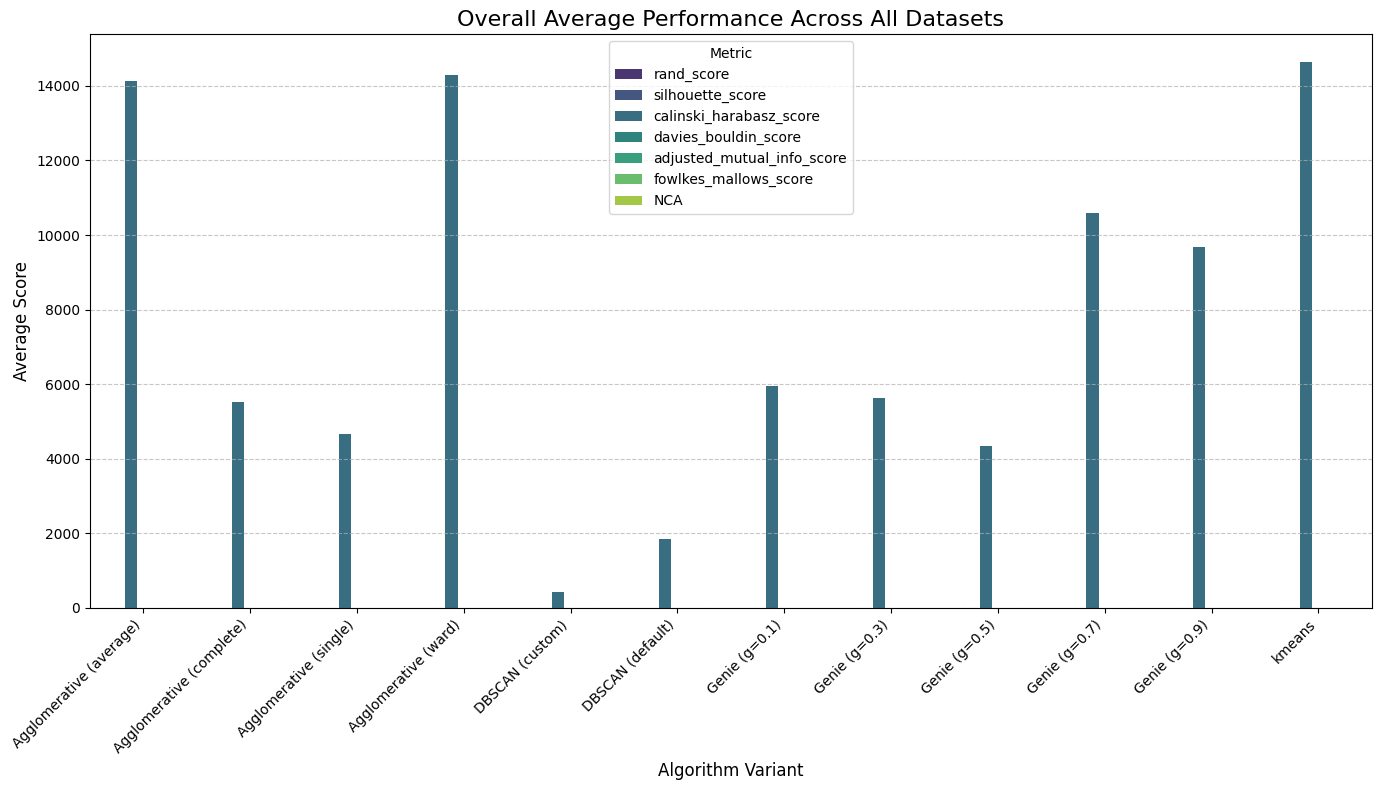


--- Generating Plot 2: Genie Hyperparameter Tuning for rand_score ---


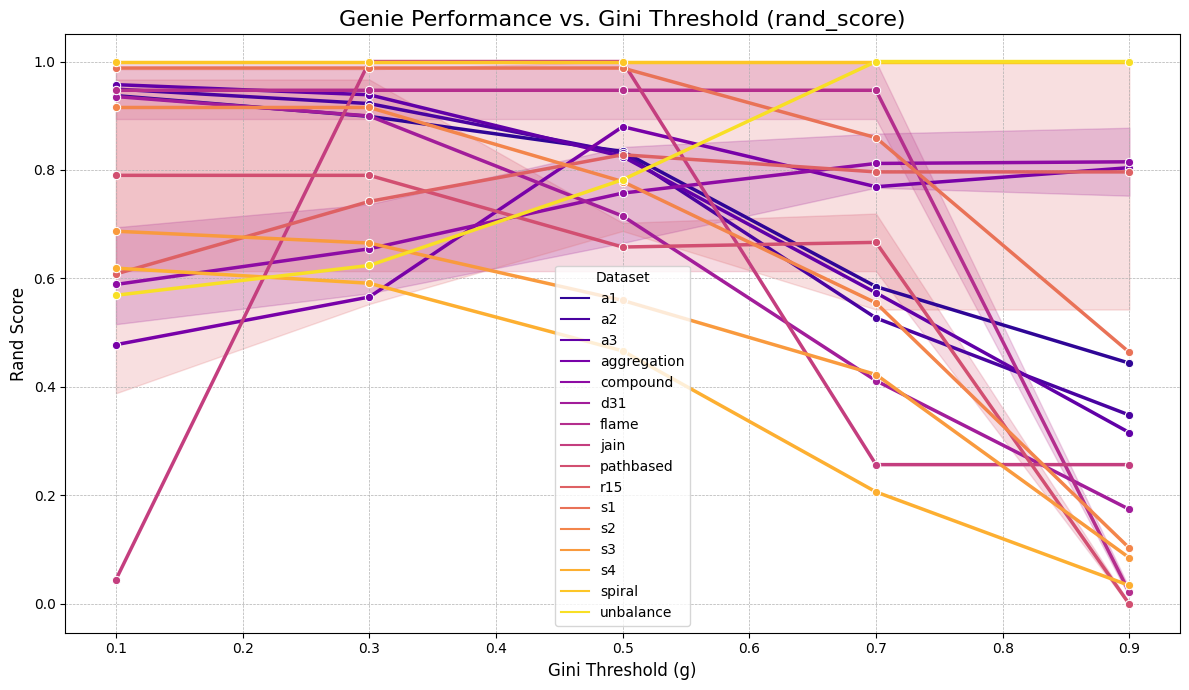


--- Generating Plot 3: Algorithm Performance by Dataset for rand_score ---


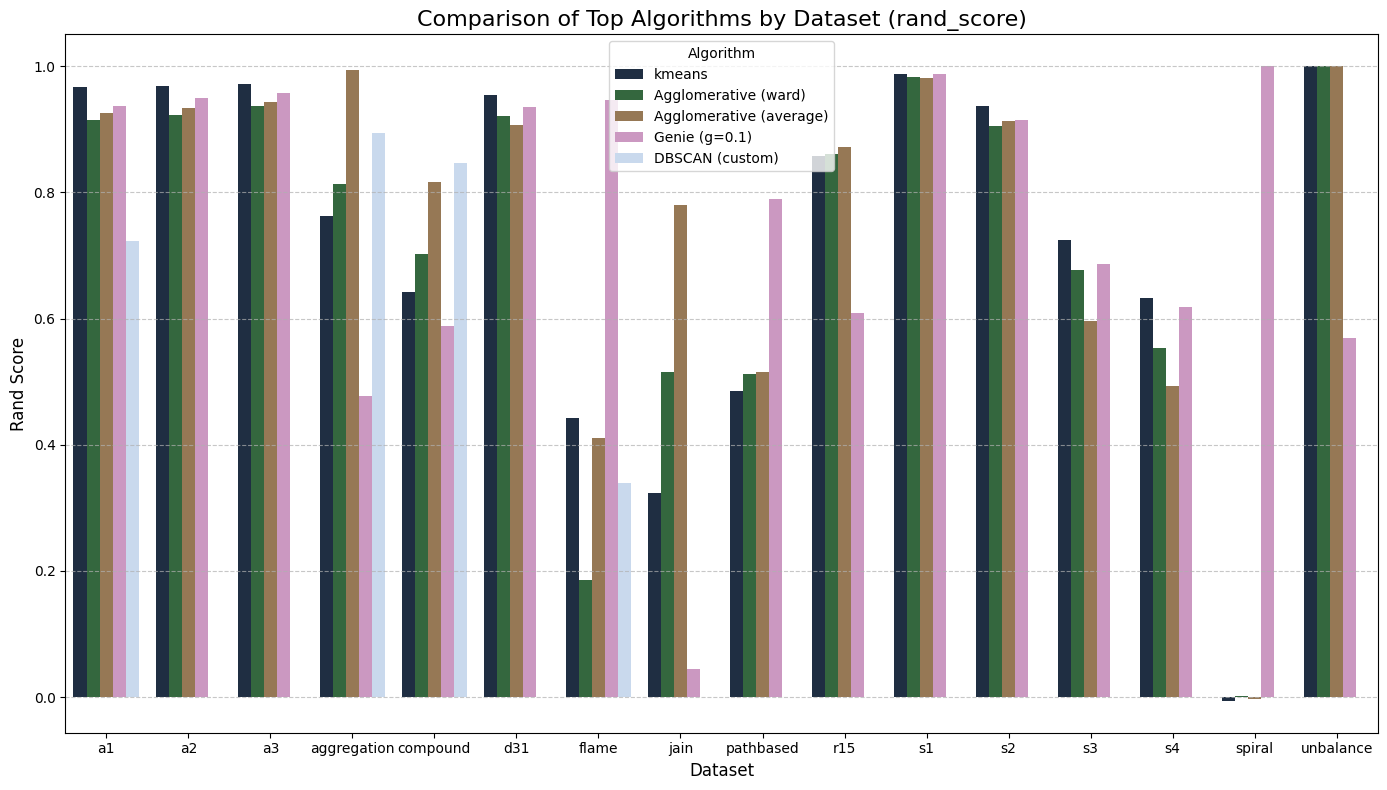

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load Your Data ---
# For this example, we'll load the data you provided.
# To use your own file, replace this block with:
df = pd.read_csv("results.csv")


# --- 2. Prepare Data for Plotting ---
# Create a more descriptive label for each algorithm variant to make plots clearer.
def create_algorithm_label(row):
    if row["method"] == "agglomerative":
        return f"Agglomerative ({row['linkage']})"
    elif row["method"] == "genie":
        # Only include default Genie runs in this label for clarity
        if row["params"] == "default":
            return f"Genie (g={row['gini_threshold']})"
    elif row["method"] == "dbscan":
        if row["params"] == "custom":
            return f"DBSCAN (custom)"
        return "DBSCAN (default)"  # Default DBSCAN performs poorly
    return row["method"]


df["algorithm_label"] = df.apply(create_algorithm_label, axis=1)

# Define a list of key external metrics to plot
METRICS_TO_PLOT = [
    "rand_score",
    "silhouette_score",
    "calinski_harabasz_score",
    "davies_bouldin_score",
    "adjusted_mutual_info_score",
    "fowlkes_mallows_score",
    "NCA",
]


# --- 3. Generate Visualizations ---


def plot_overall_performance(dataf, metrics):
    """Plots the average performance of each algorithm variant across all datasets."""
    print("--- Generating Plot 1: Overall Average Performance ---")

    # We only want to compare the 'default' parameter runs for a fair comparison,
    # plus the custom DBSCAN which worked well.
    df_plot = dataf[dataf["params"].isin(["default", "custom"])].copy()

    # Calculate the mean score for each algorithm variant
    avg_scores = df_plot.groupby("algorithm_label")[metrics].mean().reset_index()

    # Melt the dataframe to make it suitable for seaborn's barplot
    avg_scores_melted = avg_scores.melt(
        id_vars="algorithm_label", var_name="Metric", value_name="Average Score"
    )

    plt.figure(figsize=(14, 8))
    sns.barplot(
        data=avg_scores_melted,
        x="algorithm_label",
        y="Average Score",
        hue="Metric",
        palette="viridis",
    )

    plt.title("Overall Average Performance Across All Datasets", fontsize=16)
    plt.xlabel("Algorithm Variant", fontsize=12)
    plt.ylabel("Average Score", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend(title="Metric")
    plt.tight_layout()
    plt.show()


def plot_genie_hyperparameter_tuning(dataf, metric="rand_score"):
    """Plots how Genie's performance changes with its gini_threshold."""
    print(f"\n--- Generating Plot 2: Genie Hyperparameter Tuning for {metric} ---")

    df_genie = dataf[dataf["method"] == "genie"].copy()

    plt.figure(figsize=(12, 7))
    sns.lineplot(
        data=df_genie,
        x="gini_threshold",
        y=metric,
        hue="dataset",
        marker="o",
        palette="plasma",
        linewidth=2.5,
    )

    plt.title(f"Genie Performance vs. Gini Threshold ({metric})", fontsize=16)
    plt.xlabel("Gini Threshold (g)", fontsize=12)
    plt.ylabel(f'{metric.replace("_", " ").title()}', fontsize=12)
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend(title="Dataset")
    plt.tight_layout()
    plt.show()


def plot_performance_by_dataset(dataf, metric="NCA"):
    """Compares the top algorithm variants on each dataset."""
    print(f"\n--- Generating Plot 3: Algorithm Performance by Dataset for {metric} ---")

    # Let's select the best or most representative variants to avoid a cluttered plot
    top_variants = [
        "kmeans",
        "Agglomerative (ward)",
        "Agglomerative (average)",
        "Genie (g=0.1)",
        "DBSCAN (custom)",  # The one that actually worked
    ]
    df_plot = dataf[dataf["algorithm_label"].isin(top_variants)].copy()

    plt.figure(figsize=(14, 8))
    sns.barplot(
        data=df_plot,
        x="dataset",
        y=metric,
        hue="algorithm_label",
        palette="cubehelix",
        errorbar=None,
    )

    plt.title(f"Comparison of Top Algorithms by Dataset ({metric})", fontsize=16)
    plt.xlabel("Dataset", fontsize=12)
    plt.ylabel(f'{metric.replace("_", " ").title()}', fontsize=12)
    # plt.ylim(0, 1.05)  # Scores are typically between 0 and 1
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend(title="Algorithm")
    plt.tight_layout()
    plt.show()


# --- 4. Run Visualization Functions ---
if __name__ == "__main__":
    # Plot 1: The big picture
    plot_overall_performance(df, METRICS_TO_PLOT)

    # Plot 2: A deep dive into Genie's parameters
    plot_genie_hyperparameter_tuning(df, metric="rand_score")

    # Plot 3: A practical comparison on each dataset
    plot_performance_by_dataset(df, metric="rand_score")


--- Generating Plot: Wins per Algorithm per Metric ---


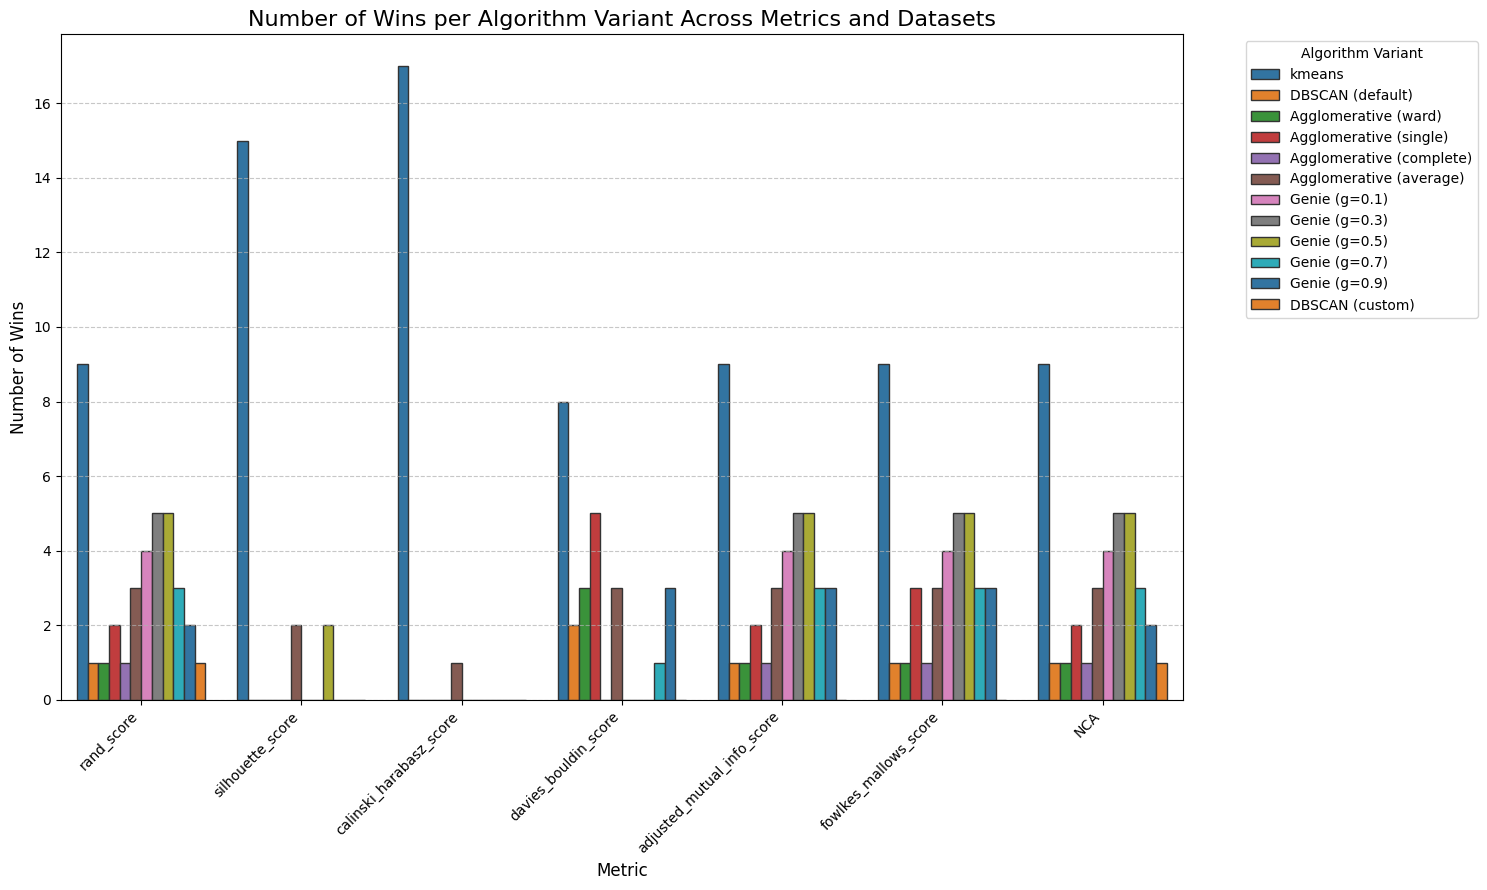

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load Your Data ---
# For this example, we'll load the data you provided.
# To use your own file, replace this block with:
df = pd.read_csv("results.csv")


# --- 2. Prepare Data for Plotting ---
# Create a more descriptive label for each algorithm variant to make plots clearer.
def create_algorithm_label(row):
    if row["method"] == "agglomerative":
        return f"Agglomerative ({row['linkage']})"
    elif row["method"] == "genie":
        # Only include default Genie runs in this label for clarity
        if row["params"] == "default":
            return f"Genie (g={row['gini_threshold']})"
    elif row["method"] == "dbscan":
        if row["params"] == "custom":
            return f"DBSCAN (custom)"
        return "DBSCAN (default)"  # Default DBSCAN performs poorly
    return row["method"]


df["algorithm_label"] = df.apply(create_algorithm_label, axis=1)

# Define a list of key metrics to plot (from your original list)
METRICS_TO_PLOT = [
    "rand_score",
    "silhouette_score",
    "calinski_harabasz_score",
    "davies_bouldin_score",
    "adjusted_mutual_info_score",
    "fowlkes_mallows_score",
    "NCA",
]

# Define metrics where a lower score is better (for determining "wins")
LOWER_IS_BETTER = ["davies_bouldin_score"]

# --- 3. Generate Visualizations ---


def plot_wins_per_algorithm_per_metric(dataf, metrics):
    """
    Plots the number of 'wins' for each algorithm variant per metric across datasets.
    A 'win' is defined as achieving the best score for a given metric on a specific dataset.
    """
    print("\n--- Generating Plot: Wins per Algorithm per Metric ---")

    # Filter for relevant algorithm variants (same as your overall performance plot)
    df_plot = dataf[dataf["params"].isin(["default", "custom"])].copy()

    # Initialize a dictionary to store win counts
    wins_data = {
        metric: {label: 0 for label in df_plot["algorithm_label"].unique()}
        for metric in metrics
    }

    # Iterate through each dataset
    for dataset_name in df_plot["dataset"].unique():
        df_dataset = df_plot[df_plot["dataset"] == dataset_name].copy()

        # Iterate through each metric
        for metric in metrics:
            if metric in df_dataset.columns:  # Check if metric exists in the dataframe
                if metric in LOWER_IS_BETTER:
                    # For metrics where lower is better, find the minimum score
                    best_score = df_dataset[metric].min()
                    # Find all algorithms that achieved this minimum score (handle ties)
                    winning_algorithms = df_dataset[df_dataset[metric] == best_score][
                        "algorithm_label"
                    ].tolist()
                else:
                    # For metrics where higher is better, find the maximum score
                    best_score = df_dataset[metric].max()
                    # Find all algorithms that achieved this maximum score (handle ties)
                    winning_algorithms = df_dataset[df_dataset[metric] == best_score][
                        "algorithm_label"
                    ].tolist()

                # Increment win counts for the winning algorithms
                for algo_label in winning_algorithms:
                    if (
                        algo_label in wins_data[metric]
                    ):  # Ensure the algorithm label exists in wins_data
                        wins_data[metric][algo_label] += 1
                    else:
                        # If a new algorithm label appears, initialize it
                        wins_data[metric][algo_label] = 1

    # Convert the wins_data dictionary to a DataFrame for plotting
    wins_df = pd.DataFrame(wins_data).T.reset_index()
    wins_df = wins_df.rename(columns={"index": "Metric"})

    # Melt the dataframe for seaborn barplot
    wins_melted = wins_df.melt(
        id_vars="Metric", var_name="Algorithm Variant", value_name="Number of Wins"
    )

    plt.figure(figsize=(15, 9))
    sns.barplot(
        data=wins_melted,
        x="Metric",
        y="Number of Wins",
        hue="Algorithm Variant",
        palette="tab10",  # A different palette for variety
        edgecolor=".2",
    )

    plt.title(
        "Number of Wins per Algorithm Variant Across Metrics and Datasets", fontsize=16
    )
    plt.xlabel("Metric", fontsize=12)
    plt.ylabel("Number of Wins", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend(title="Algorithm Variant", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


# --- 4. Run Visualization Function ---
if __name__ == "__main__":
    plot_wins_per_algorithm_per_metric(df, METRICS_TO_PLOT)